In [63]:
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [67]:
def f(z):
	return jnp.pi / (jnp.tan(jnp.pi * z) * z ** 2)

num = 1000
N = 4
M = N + 1
x = (M + 0.5) * (2 * jnp.linspace(0, 1, num) - 1)
y = M * (2 * jnp.linspace(0, 1, num) - 1)
X, Y = jnp.meshgrid(x, y)
Z = X + 1j * Y

mod_fz = jnp.abs(f(Z))



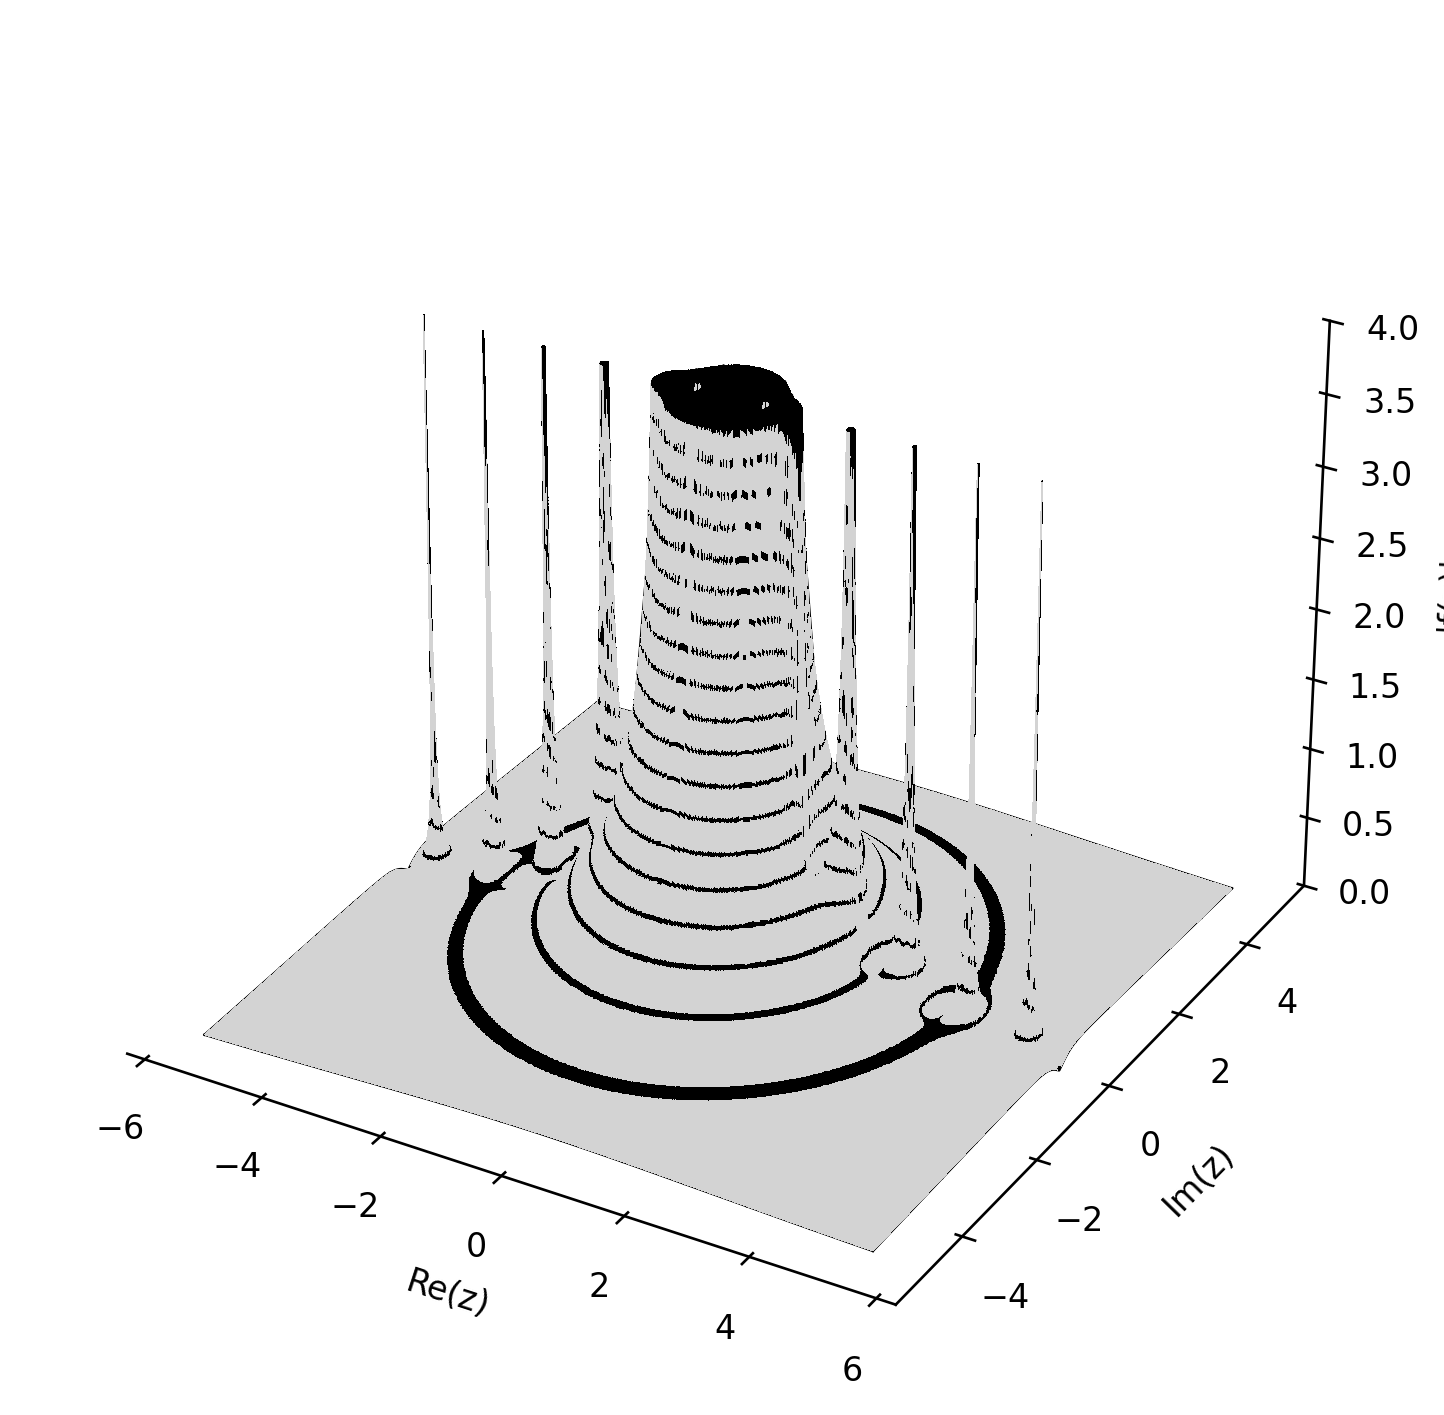

In [68]:
mod_np = onp.nan_to_num(onp.array(mod_fz), nan=0.0, posinf=0.0)
cap = onp.nanpercentile(mod_np[onp.isfinite(mod_np) & (mod_np > 0)], 99) if onp.any(onp.isfinite(mod_np)) else 1.0
mod_capped = onp.minimum(mod_np, cap)

max_z = 4
mod_capped = onp.minimum(mod_capped, max_z)

X_np, Y_np = onp.array(X), onp.array(Y)
# num const sets
n_slice = 12

fig = plt.figure(figsize=(8, 6), dpi=240)
ax = fig.add_subplot(111, projection="3d")

levels = onp.linspace(mod_capped.min(), mod_capped.max(), 20)
eps = 0.03

# width of the black contour bands
dz = levels[1] - levels[0]
band_halfwidth = 0.06 * dz

dist_to_level = onp.min(
  onp.abs(mod_capped[..., None] - levels[None, None, :]),
  axis=-1
)

# build RGBA facecolors
facecolors = onp.empty(mod_capped.shape + (4,), dtype=float)
facecolors[...] = mcolors.to_rgba("lightgrey")
facecolors[dist_to_level < band_halfwidth] = mcolors.to_rgba("black")


surf = ax.plot_surface(
	X_np, Y_np, mod_capped, 
	facecolors=facecolors,

	# cmap=None, color='lightgrey', alpha=0.5,
	shade=False,
	antialiased=False,
	linewidth=0,
	rstride=1, cstride=1,
)


# tmp_fig, tmp_ax = plt.subplots()
# cs = tmp_ax.contour(X_np, Y_np, mod_capped, levels=levels)
# plt.close(tmp_fig)

# for level, segs in zip(cs.levels, cs.allsegs):
#   for seg in segs:
#     if len(seg) > 1:
#       ax.plot(
#         seg[:, 0],
#         seg[:, 1],
#         (level + eps) * onp.ones(seg.shape[0]),
#         color="k",
#         linewidth=0.8,
#       )

# ax.contour(X_np, Y_np, mod_capped, levels=20, colors="k", linewidths=0.6)
# const Re(z)
for i in onp.linspace(0, X_np.shape[1] - 1, n_slice, dtype=int):
	ax.plot(X_np[:, i], Y_np[:, i], mod_capped[:, i], "k", linewidth=0.7)
# const Im(z):
for j in onp.linspace(0, X_np.shape[0] - 1, n_slice, dtype=int):
	ax.plot(X_np[j, :], Y_np[j, :], mod_capped[j, :], "k", linewidth=0.7)
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_zlabel("|f(z)|")
ax.set_zlim(0, max_z)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")
ax.grid(False)
plt.tight_layout()
plt.show()



/var/folders/fr/n59gclp95830bd9kqj0dy7hr0000gn/T/ipykernel_5428/280676863.py:61: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


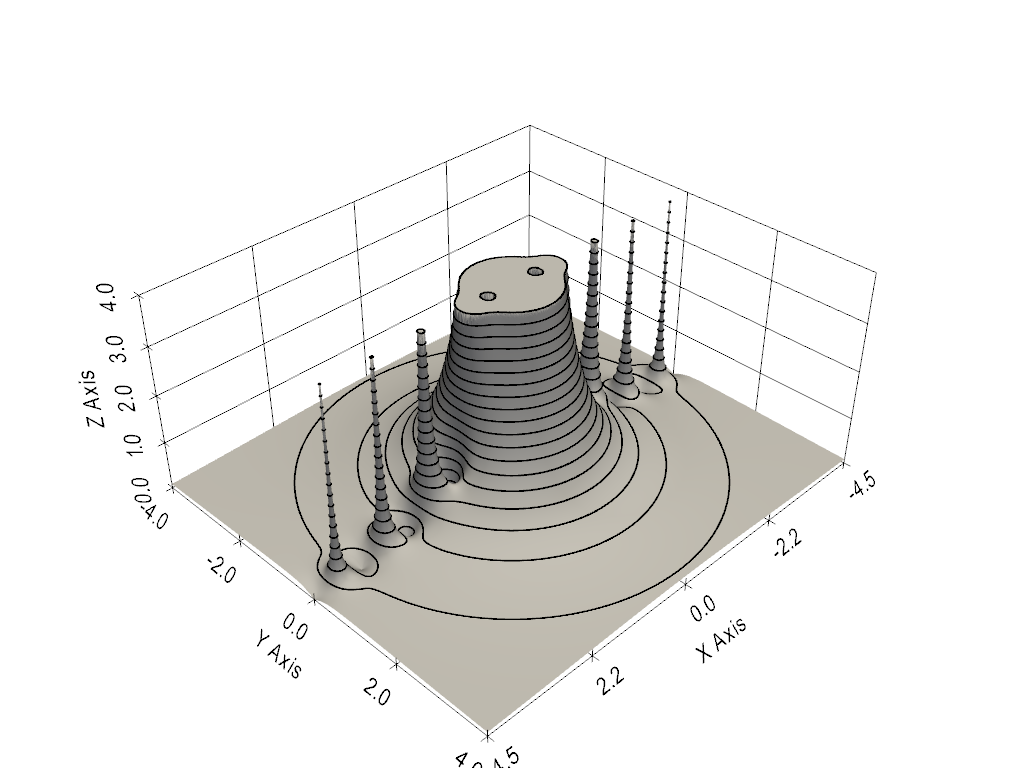

In [77]:
import jax.numpy as jnp
import numpy as onp
import pyvista as pv

def f(z):
  return jnp.pi / (jnp.tan(jnp.pi * z) * z ** 2)

num = 1000
N = 3
M = N + 1

x = (M + 0.5) * (2 * jnp.linspace(0, 1, num) - 1)
y = M * (2 * jnp.linspace(0, 1, num) - 1)
X, Y = jnp.meshgrid(x, y)
Z = X + 1j * Y

mod_fz = jnp.abs(f(Z))

mod_np = onp.nan_to_num(onp.array(mod_fz), nan=0.0, posinf=0.0)
cap = onp.nanpercentile(
  mod_np[onp.isfinite(mod_np) & (mod_np > 0)],
  99
) if onp.any(onp.isfinite(mod_np)) else 1.0

max_z = 4.0
mod_capped = onp.minimum(mod_np, cap)
mod_capped = onp.minimum(mod_capped, max_z)

X_np = onp.array(X)
Y_np = onp.array(Y)

# Build the actual surface z = mod_capped(x, y)
grid = pv.StructuredGrid(X_np, Y_np, mod_capped)

# Attach the same scalar field used as height.
# For StructuredGrid, Fortran order is the safe choice.
grid["u"] = mod_capped.ravel(order="F")

levels = onp.linspace(float(mod_capped.min()), float(mod_capped.max()), 20)

# Extract true contour curves on the surface
contours = grid.contour(isosurfaces=levels, scalars="u")

pl = pv.Plotter()
pl.add_mesh(
  grid,
  color="lightgrey",
  smooth_shading=True,
  show_edges=False,
  opacity=1.0
)
pl.add_mesh(
  contours,
  color="black",
  line_width=2,
  render_lines_as_tubes=True
)

pl.show_grid()
# pl.show_axes()
pl.show()

from mpl_toolkits.mplot3d import Axes3D

# Convert to numpy for plotting; cap magnitude so poles don't flatten the surface
mod_np = onp.nan_to_num(onp.array(mod_fz), nan=0.0, posinf=0.0)
cap = onp.nanpercentile(mod_np[onp.isfinite(mod_np) & (mod_np > 0)], 99) if onp.any(onp.isfinite(mod_np)) else 1.0
mod_capped = onp.minimum(mod_np, cap)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(onp.array(X), onp.array(Y), mod_capped, cmap="viridis", rstride=2, cstride=2, alpha=0.9)
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_zlabel("|f(z)|")
plt.tight_layout()
plt.show()

mod_np = onp.nan_to_num(onp.array(mod_fz), nan=0.0, posinf=0.0)
cap = onp.nanpercentile(mod_np[onp.isfinite(mod_np) & (mod_np > 0)], 99) if onp.any(onp.isfinite(mod_np)) else 1.0
mod_capped = onp.minimum(mod_np, cap)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(onp.array(X), onp.array(Y), mod_capped, levels=20, cmap="gray")
ax.contour(onp.array(X), onp.array(Y), mod_capped, levels=20, colors="k", linewidths=0.4)
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


In [ ]:
mod_np = onp.nan_to_num(onp.array(mod_fz), nan=0.0, posinf=0.0)
cap = onp.nanpercentile(mod_np[onp.isfinite(mod_np) & (mod_np > 0)], 99) if onp.any(onp.isfinite(mod_np)) else 1.0
mod_capped = onp.minimum(mod_np, cap)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.contour(onp.array(X), onp.array(Y), mod_capped, levels=50, colors="k", linewidths=0.6)
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_zlabel("|f(z)|")
# Textbook style: no filled axis faces
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")
ax.grid(False)
plt.tight_layout()
plt.show()

